In [13]:
import cv2
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import decord
import json
import os
from tqdm.notebook import tqdm

In [ ]:
# Load video
video_path = r'/home/share/schaer2/idtracking_keypoint/demo/video_25-09-05-14-40-56_c0.mp4'
# cap = cv2.VideoCapture(video_path)
vr = decord.VideoReader(video_path)
# Load JSON file
json_path = r'/home/share/schaer2/idtracking_keypoint/demo/video_25-09-05-14-40-56_c0_mask_0-206_20250905_151446.json'
output_dir = r'/home/share/schaer2/idtracking_keypoint/demo'
os.makedirs(output_dir, exist_ok=True)
with open(json_path, 'r') as f:
    mask_data = json.load(f)

width, height = vr[0].shape[1], vr[0].shape[0]
print(f"Width: {width}, Height: {height}")

Width: 1920, Height: 1080


In [15]:
video_source_mask = r"/home/share/schaer2/idtracking_keypoint/demo/video_25-09-05-14-40-56_c0.mp4"
cap = cv2.VideoCapture(video_source_mask)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()
print(f"Width: {width}, Height: {height}")

Width: 1920, Height: 1080


In [16]:
# Compute the scaling ratios between the mask source video and the vr video
cap = cv2.VideoCapture(video_source_mask)
src_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
src_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

vr_width = vr[0].shape[1]
vr_height = vr[0].shape[0]

ratio_x = vr_width / src_width
ratio_y = vr_height / src_height

print(f"Scale ratios - X: {ratio_x}, Y: {ratio_y}")

Scale ratios - X: 1.0, Y: 1.0


In [17]:
def rle_to_mask(rle) -> np.ndarray:
    """Compute a binary mask from an uncompressed RLE."""
    h, w = rle["size"]
    mask = np.empty(h * w, dtype=bool)
    idx = 0
    parity = False
    for count in rle["counts"]:
        mask[idx : idx + count] = parity
        idx += count
        parity ^= True
    mask = mask.reshape(w, h)
    return mask.transpose()  # Put in C order


def show_mask(mask, ax, obj_id=None, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        cmap = plt.get_cmap("tab10")
        cmap_idx = 0 if obj_id is None else obj_id
        color = np.array([*cmap(cmap_idx)[:3], 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def show_points(coords, labels, ax, marker_size=200):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)


def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))

In [30]:
mask_data['frames'][110]

{'idx': 110,
 'masks': {'target_ids': [1],
  'rle_masks': [{'size': [1080, 1920],
    'counts': [1070180,
     1,
     1074,
     11,
     1036,
     6,
     23,
     17,
     1030,
     14,
     15,
     23,
     1024,
     20,
     10,
     27,
     1019,
     25,
     6,
     31,
     1014,
     66,
     1010,
     71,
     1005,
     75,
     757,
     33,
     211,
     80,
     746,
     53,
     197,
     84,
     742,
     63,
     187,
     88,
     739,
     71,
     178,
     92,
     737,
     78,
     169,
     97,
     734,
     82,
     163,
     101,
     610,
     4,
     1,
     7,
     109,
     88,
     156,
     105,
     574,
     23,
     6,
     25,
     96,
     97,
     151,
     108,
     570,
     60,
     91,
     103,
     145,
     111,
     566,
     66,
     86,
     108,
     139,
     115,
     558,
     76,
     81,
     115,
     132,
     118,
     553,
     97,
     3,
     10,
     46,
     123,
     126,
     122,
     549,
     145,
     8,
   

In [18]:
def get_mask(frame_number, mask_data):
    """Retrieve the masks associated with a specific frame."""
    frames = mask_data.get('frames')
    if frame_number < len(frames):
        frame = frames[frame_number]
        points = frame.get('points', {})
        bboxs = frame.get('bboxs', {})
        masks =  frame.get('masks', [])
        return points, bboxs, masks
    return None

In [19]:
# Define colors for each target_id
colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255), (0, 255, 255)]


In [24]:
mask_data

{'message': 'Propagation for None completed!',
 'video_name': 'video_25-09-05-14-40-56_c0.mp4',
 'frames': [{'idx': 0,
   'bboxs': [{'0': {'1': {'bbox': [1100, 388, 1349, 1028]}}},
    {'0': {'1': {'bbox': [1100, 388, 1349, 1028]}}}],
   'masks': {'target_ids': [1],
    'rle_masks': [{'size': [1080, 1920],
      'counts': [1211647,
       7,
       906,
       10,
       155,
       12,
       900,
       15,
       151,
       16,
       893,
       23,
       148,
       18,
       888,
       29,
       144,
       21,
       883,
       33,
       141,
       25,
       878,
       37,
       139,
       27,
       873,
       43,
       136,
       30,
       868,
       47,
       135,
       30,
       865,
       52,
       133,
       31,
       860,
       56,
       133,
       32,
       856,
       60,
       131,
       34,
       852,
       64,
       130,
       35,
       847,
       69,
       129,
       36,
       842,
       73,
       129,
       37,
       838,


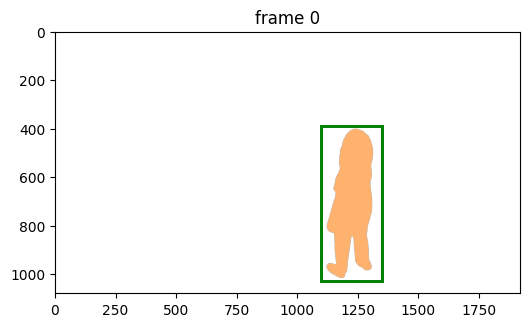

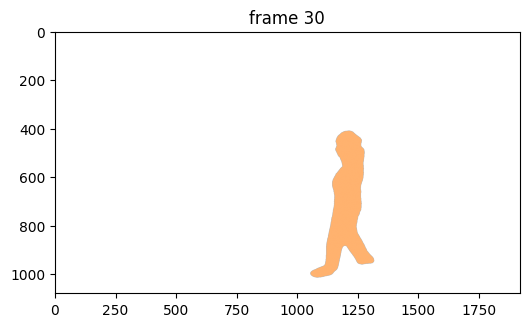

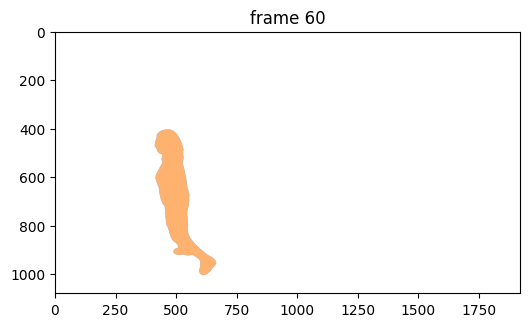

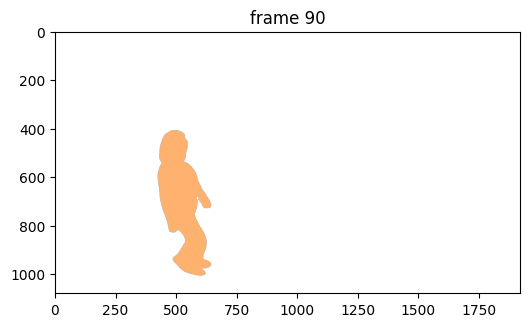

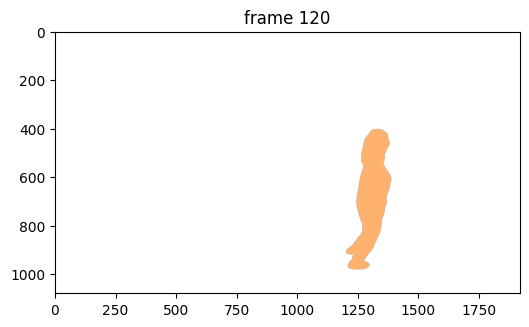

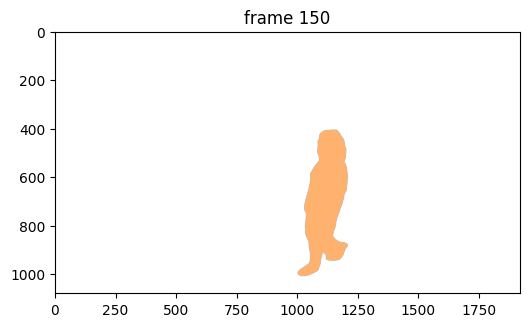

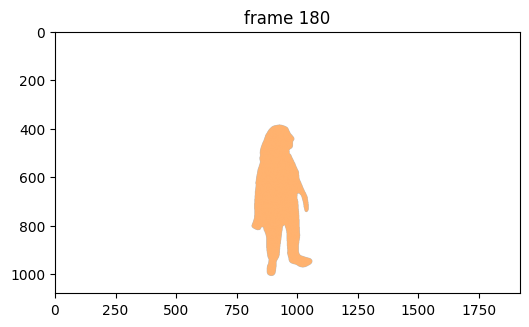

In [ ]:
step = len(vr)//10 +1
for last_id in range(0, len(vr), 30):
    frame = vr[last_id].asnumpy()
    plt.figure(figsize=(6, 4))
    plt.title(f"frame {last_id}")
    plt.imshow(frame)

    points, bboxs, masks = get_mask(last_id, mask_data)
    if masks:
        for target_id, rle_mask in zip(masks.get('target_ids'), masks.get('rle_masks')):
            mask = rle_to_mask(rle_mask)
            # Resize mask to match vr frame size using the ratios
            # mask_resized = cv2.resize(mask.astype(np.uint8), (vr_width, vr_height), interpolation=cv2.INTER_NEAREST)
            # show_mask(mask_resized.astype(bool), ax=plt.gca(), obj_id=target_id)
            show_mask(mask.astype(bool), ax=plt.gca(), obj_id=target_id)
    if bboxs:
        for un_truc in bboxs:
            un_trutruc = un_truc[str(last_id)]
            for target_id in un_trutruc.keys():
                bbox = un_trutruc[str(target_id)]['bbox']
                # Scale bbox coordinates to vr frame size
                bbox_scaled = [
                    int(bbox[0] * ratio_x),
                    int(bbox[1] * ratio_y),
                    int(bbox[2] * ratio_x),
                    int(bbox[3] * ratio_y)
                ]
                show_box(bbox_scaled, ax=plt.gca())
    if points:
        for point in points:
            point = point[str(last_id)]
            for target_id in point.keys():
                pt = np.array([point[target_id]['point']])
                # Scale point coordinates to vr frame size
                pt_scaled = pt * [ratio_x, ratio_y]
                show_points(pt_scaled, np.array([point[target_id]['label']]), ax=plt.gca())
